# Config

## Imports

In [ ]:
import logging

logging.basicConfig(
    level=logging.WARNING,
    # level=logging.INFO,
    # level=logging.DEBUG,
    format="%(asctime)s [%(levelname)s] %(module)s.%(funcName)s(): %(message)s"
)
logger = logging.getLogger(__name__)

import os
import sys

import pandas as pd

from pathlib import Path
from matplotlib import pyplot as plt
from pprint import pprint
from time import perf_counter
from tqdm import tqdm
from typing import List

# sys.path.append(str(Path(__file__).parent.parent / 'src'))

from fjsspw_solver import GeneticAlgorithm, Individual, Encoding, GAParams
from fjsspw_solver.genetic_algorithm import Method, MethodParams
from fjsspw_solver.plotting import plot_fjsspw_gantt_on_ax, plot_learning_progress, plot_learning_progress_on_ax, PlottingParams, plot_multiple_instance_runs
from fjsspw_solver.utils import get_next_filename

from util.benchmark_parser import WorkerBenchmarkParser
from util.uncertainty import create_uncertainty_vector
from util.graph import Graph

from constants import *

instances_root = Path("../../instances/fjssp-w/")
output_root = Path("../../out/logs")

# Helpers

In [ ]:
def visualize(instance: str, verbose: bool = False, run: int = 0):
    instance_log = output_root / instance / f"run_{run}"
    config_file = instance_log / "config.cfg"
    log_file = instance_log / "evolution.log"
    out_file = instance_log / "best.out"
    if not instance_log.is_dir() or not log_file.is_file() or not out_file.is_file():
        return

    if verbose:
        print(output_root)
        print(log_file)
        print(out_file)
    
    parser = WorkerBenchmarkParser()
    encoding = parser.parse_benchmark(str(instances_root / f"{instance}.fjs"))

    encoding = Encoding(encoding.durations().tolist(), encoding.job_sequence())

    if verbose:
        print("-" * 20)
        print("Encoding info")
        print("n_operations:", encoding.n_operations())
        print("n_machines:", encoding.n_machines())
        print("n_workers:", encoding.n_workers())
        print("n_jobs:", encoding.n_jobs())
        print("-" * 20)

        print(encoding.get_job_sequence())
    
    plotting_params = PlottingParams(
        instance_name = "".join(instance.lower().split("_")[1:-1]),
        bounds_file = "../../instances/InstanceData/FJSSP-W/new_best_known.csv",
        selection_type = "Tournament",
        crossover_type = "MOX",
        mutation_type = "Mixed"
    )
    def plot_gantt_on_ax(ax, out_file, fontsize=12, show_legend=True):
        with open(out_file, mode='r') as f:
            fitness = float(f.readline())
            sequence = [int(x) for x in f.readline().split(',')]
            machines = [int(x) for x in f.readline().split(',')]
            workers = [int(x) for x in f.readline().split(',')]
            start_times = [float(x) for x in f.readline().split(',')]
            end_times = [float(x) for x in f.readline().split(',')]
        plot_fjsspw_gantt_on_ax(ax, sequence, machines, workers, start_times, end_times, encoding, instance, fitness, fontsize=fontsize, show_legend=show_legend)

    
    fig, axes = plt.subplots(3, 1, figsize=(24, 24))
    plot_learning_progress_on_ax(axes[0], log_file, plotting_params)
    plot_learning_progress_on_ax(axes[1], log_file, plotting_params, zoom=True)
    # plot_gantt(out_file, fontsize=8, show_legend=False)
    plot_gantt_on_ax(axes[2], out_file, show_legend=False)
    plt.tight_layout()
    plt.show()

def visualize_weights(instance: str):
    df = pd.read_csv(output_root / instance / "run_0" / "evolution.log")
    df = df.drop(columns=["worst", "avg", "best", "best_so_far", "evals"])
    df.plot(x="generation", grid=True, figsize=(12, 8))

## Instance setup

In [ ]:
def run_ga(instance: str) -> int:
    parser = WorkerBenchmarkParser()
    encoding = parser.parse_benchmark(str(instances_root / f"{instance}.fjs"))

    encoding = Encoding(encoding.durations().tolist(), encoding.job_sequence())
    uncertainty_parameters = create_uncertainty_vector(encoding.n_operations(), factor=10.0, offset=1.0)

    def uncertain_eval_function(sequence, machines, workers, start_times, end_times, iters: int = 1) -> List|float:
        logger.debug(
                    f"sequence={sequence}"
                    f", machines={machines}"
                    f", workers={workers}"
                    f", job_sequence={encoding.get_job_sequence()}"
                    f", start_times={start_times}"
                    f", end_times={end_times}")
        fitnesses = [0] * iters
        for i in range(iters):
            g = Graph(start_times, end_times, machines, workers, encoding.get_job_sequence())
            g.simulate(encoding.get_durations(), uncertainty_parameters, processing_times=True)
            fitnesses[i] = max(g.e)
        return fitnesses

    params = MethodParams(
        ga_params = GAParams.load(),
        fitness_fun_evals = 5_000_000,
        fitness_fun_evals_per_indv = 3, 
    )
    
    ga = Method(params, encoding, uncertain_eval_function)
    
    fitness = ga.solve()
    
    return fitness

In [3]:
def deterministic_eval_function(indv: Individual, iters: int = 1) -> float:
    return indv.get_internal_fitness()

def uncertain_eval_function(indv: Individual, iters: int = 1) -> List|float:
    logger.debug(f"Enter uncertain eval function: indv={indv.to_string()}")
    sequence, machines, workers, start_times, end_times = indv.get_representation()
    logger.debug(
                 f"sequence={sequence}"
                 f", machines={machines}"
                 f", workers={workers}"
                 f", job_sequence={encoding.get_job_sequence()}"
                 f", start_times={start_times}"
                 f", end_times={end_times}")
    fitnesses = [0] * iters
    for i in range(iters):
        g = Graph(start_times, end_times, machines, workers, encoding.get_job_sequence())
        g.simulate(encoding.get_durations(), uncertainty_parameters, processing_times=True)
        fitnesses[i] = max(g.e)
    return fitnesses if iters > 1 else fitnesses[0]

In [4]:
def evaluate_custom_method_with_params(method_class, params: MethodParams, encoding: Encoding, gantt: bool = False, zoom: bool = False):
    method = method_class(params, encoding, deterministic_eval_function)
    best_indv = method.solve()
    print(best_indv.get_representation())
    plot_single_instance_single_run(method, gantt)
    if zoom:
        c = best_indv.get_internal_fitness()
        robust_c = method.fitness_fun(best_indv)
        plot_learning_progress(method.get_log_file_path(),
                            params, c=c, robust_c=robust_c, zoom=zoom)
    return best_indv

def evaluate_method_with_params(params: MethodParams, encoding: Encoding, gantt: bool = False, zoom: bool = False):
    return evaluate_custom_method_with_params(Method, params, encoding, gantt, zoom)

In [5]:
def evaluate_method_with_params_for_stats(params: MethodParams, encoding: Encoding, n: int, runs: Optional[list] = None):
    method = None
    if not runs:
        runs = []
        for i in range(n):
            method = Method(params, encoding, deterministic_eval_function)
            best_indv = method.solve()
            
            c = best_indv.get_internal_fitness()
            robust_c = deterministic_eval_function(best_indv)
            runs.append((c, robust_c, method.get_log_file_path()))
    plot_multiple_instance_runs(params, runs)
    return runs

In [6]:
pprint(base_method_params)

MethodParams(fitness_fun_evals=5000000,
             fitness_fun_evals_per_indv=1,
             generations=10,
             population_size=10,
             selection_params=SelectionParams(reset_period=100,
                                              selection=<Selections.TOURNAMENT: (2,)>,
                                              size=5),
             crossover_params=CrossoverParams(reset_period=100,
                                              crossover=<Crossovers.MOX: (1,)>,
                                              crossover_prob=0.0),
             mutation_params=MutationParams(reset_period=100,
                                            mutation=<Mutations.ADAPTIVE: (8,)>,
                                            mutation_prob=1.0,
                                            gene_swap_prob=1.0,
                                            machine_swap_prob=1.0,
                                            worker_swap_prob=1.0,
                                   

# Sanity check

## Instances descriptions

In [7]:
instance_data = pd.read_csv(INSTANCE_DATA_SELECTED_PATH)
instance_data_groupped = instance_data.groupby("type")
instance_data

,source,n_operations,flexibility,duration_variety,n_machines,n_jobs,average_operations_per_job,d_max,d_min,d_distinct,d_unique,d_shared,d_average,n_worker,type
0,Hurinkvdata55,49,0.259184,0.595051,7,7,7.00,1054,2,529,313,216,485.680540,10,small
1,Fattahi9,9,0.416667,0.755556,3,3,3.00,108,16,34,25,9,55.822222,4,small
2,BrandimarteMk6,150,0.171200,0.002596,10,10,15.00,10,1,10,0,10,5.010903,15,medium
3,Hurinkvdata28,150,0.261956,0.017645,10,15,10.00,109,5,104,0,104,49.427044,15,medium
4,ChambersBarnes10,150,0.056086,0.050048,13,15,10.00,109,5,104,2,102,54.177093,19,medium
5,Hurinksdata34,300,0.055133,0.041516,10,30,10.00,107,5,103,0,103,50.275292,15,large
6,Hurinkedata34,300,0.058489,0.039514,10,30,10.00,108,5,104,1,103,52.518997,15,large
7,Hurinkrdata34,300,0.103933,0.022236,10,30,10.00,108,5,104,2,102,51.367329,15,large
8,Hurinkvdata34,300,0.240244,0.009620,10,30,10.00,108,5,104,0,104,52.294515,15,large
9,Behnke20,500,0.163787,0.000509,20,100,5.00,33,9,25,0,25,20.032563,30,dense


## Method params

In [8]:
method_params = MethodParams(
    generations=10,
    population_size=10,
    clones_removal=ClonesRemoval.GLOBAL,
    selection_params=SelectionParams(
        size=3,
        selection=Selections.TOURNAMENT,
    ),
    crossover_params=CrossoverParams(
        crossover_prob=0.6,
        crossover=Crossovers.MOX,
    ),
    mutation_params=MutationParams(
        mutation_prob = 1.0,
        gene_swap_prob = 1.0,
        machine_swap_prob = 1.0,
        worker_swap_prob = 1.0,
        machine_replace_prob = 1.0,
        worker_replace_prob = 1.0,
        mutation=Mutations.ADAPTIVE,
    ),
    fitness_fun_evals_per_indv=3,
    instance_name=instance_name,
    bounds_file=INSTANCE_DATA_FJSSPW_PATH / "best_known.csv",
)

## Run method

In [9]:
pprint(method_params)

MethodParams(fitness_fun_evals=5000000,
             fitness_fun_evals_per_indv=3,
             generations=10,
             population_size=10,
             selection_params=SelectionParams(reset_period=100,
                                              selection=<Selections.TOURNAMENT: (2,)>,
                                              size=3),
             crossover_params=CrossoverParams(reset_period=100,
                                              crossover=<Crossovers.MOX: (1,)>,
                                              crossover_prob=0.6),
             mutation_params=MutationParams(reset_period=100,
                                            mutation=<Mutations.ADAPTIVE: (8,)>,
                                            mutation_prob=1.0,
                                            gene_swap_prob=1.0,
                                            machine_swap_prob=1.0,
                                            worker_swap_prob=1.0,
                                   

In [10]:
logger.info("Init method")
method = Method(method_params, encoding, uncertain_eval_function)
logger.info("Finish init method")

In [11]:
best_indv = method.solve()

Solving: 100%|██████████| 10/10 [00:00<00:00, 31.92it/s]
2026-04-27 14:37:12,143 [WARNING] genetic_algorithm.solve(): Found 0/100 clones total. 0 clones replaced with a random Individual


## Evaluate

In [12]:
sequence, machines, workers, start_times, end_times = best_indv.get_representation()
sequence, machines, workers, start_times, end_times

([10,
  7,
  6,
  4,
  0,
  1,
  2,
  10,
  5,
  9,
  9,
  8,
  6,
  5,
  11,
  1,
  10,
  0,
  8,
  7,
  11,
  0,
  4,
  3,
  1,
  2,
  6,
  10,
  5,
  3,
  5,
  7,
  11,
  3,
  8,
  11,
  2,
  4,
  9,
  6,
  4,
  7,
  0,
  1,
  9,
  3,
  2,
  8],
 [2,
  6,
  6,
  7,
  0,
  1,
  4,
  4,
  0,
  3,
  5,
  5,
  0,
  2,
  3,
  5,
  0,
  4,
  5,
  7,
  1,
  3,
  5,
  3,
  1,
  2,
  6,
  7,
  2,
  4,
  4,
  7,
  1,
  3,
  6,
  7,
  3,
  4,
  6,
  6,
  1,
  2,
  6,
  5,
  1,
  4,
  5,
  7],
 [1,
  0,
  1,
  4,
  11,
  3,
  5,
  2,
  11,
  2,
  6,
  11,
  2,
  5,
  0,
  9,
  6,
  11,
  5,
  8,
  10,
  5,
  10,
  6,
  9,
  1,
  0,
  7,
  6,
  0,
  3,
  3,
  1,
  4,
  1,
  8,
  9,
  10,
  4,
  1,
  6,
  6,
  9,
  10,
  5,
  4,
  1,
  10],
 [0,
  99,
  229,
  440,
  0,
  587,
  1390,
  1709,
  199,
  887,
  1510,
  1907,
  279,
  1030,
  1308,
  1751,
  368,
  1338,
  1664,
  1751,
  299,
  535,
  955,
  1191,
  135,
  674,
  1081,
  1245,
  135,
  816,
  1578,
  1904,
  441,
  682,
  887,
  933

In [13]:
if PROD:
    assert len(sequence) > 0, "The sequence should not be empty."
    assert len(machines) > 0, "The number of machines should not be empty."
    assert len(workers) > 0, "The number of workers should not be empty."
    assert len(start_times) > 0, "The number of start_times should not be empty."
    assert len(end_times) > 0, "The number of end_times should not be empty."

In [14]:
# start_times, machines, workers = evaluation.translate(sequence, machines, workers, encoding.get_durations()) # necessary because the solver does not provide the start times of the schedule
# c = evaluation.makespan(start_times, machines, workers, encoding.get_durations())
c = best_indv.get_internal_fitness()
robust_c = uncertain_eval_function(best_indv)
print(f'Makespan: {c}')
print(f'Robust makespan: {robust_c}')

Makespan: 2068
Robust makespan: 4254.449141482111


## Plot results

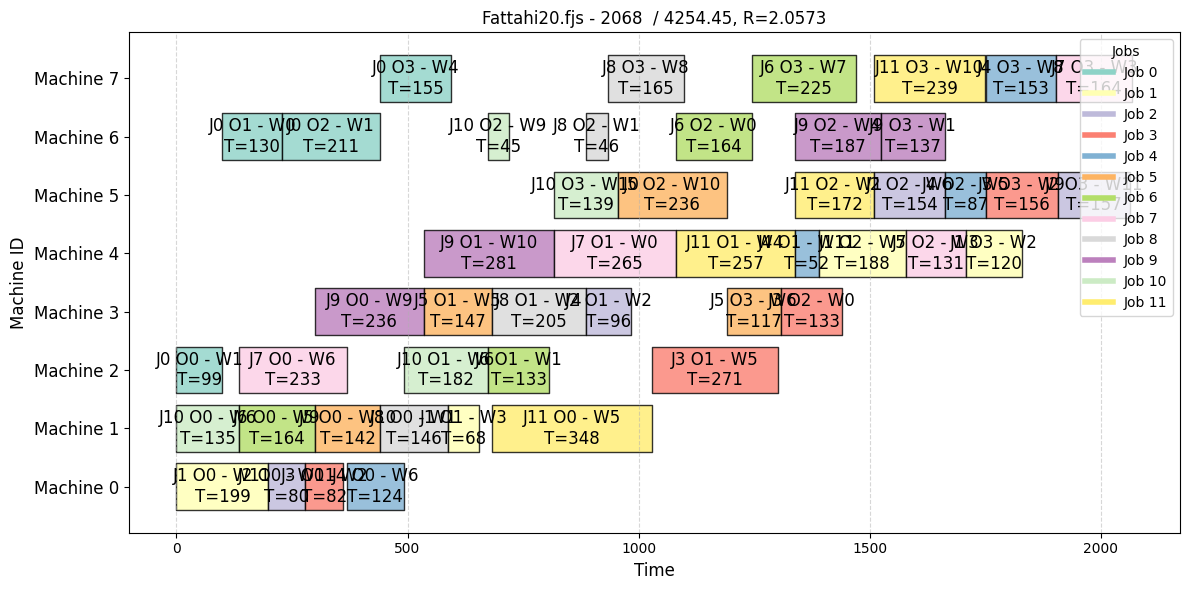

In [15]:
plot_fjsspw_gantt(sequence, machines, workers, start_times, end_times, encoding=encoding, instance_name=instance_name, c=c, robust_c=robust_c)

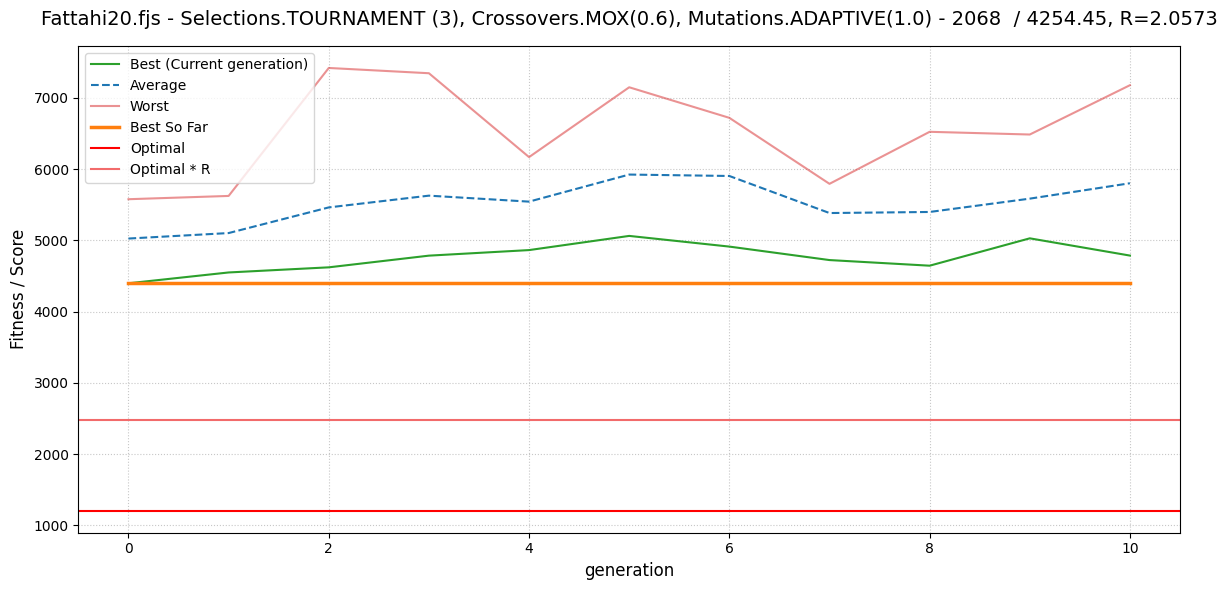

In [16]:
plot_learning_progress(method.get_log_file_path(), method_params, c=c, robust_c=robust_c)

# Run experiment from config

In [22]:
pprint(base_method_params)

MethodParams(fitness_fun_evals=5000000,
             fitness_fun_evals_per_indv=3,
             generations=500,
             population_size=100,
             selection_params=SelectionParams(reset_period=100,
                                              selection=<Selections.TOURNAMENT: (2,)>,
                                              size=5),
             crossover_params=CrossoverParams(reset_period=100,
                                              crossover=<Crossovers.POX: 2>,
                                              crossover_prob=0.4),
             mutation_params=MutationParams(reset_period=100,
                                            mutation=<Mutations.ADAPTIVE: (8,)>,
                                            mutation_prob=0.05,
                                            gene_swap_prob=0.05,
                                            machine_swap_prob=0.05,
                                            worker_swap_prob=0.05,
                                

Solving: 100%|██████████| 500/500 [00:08<00:00, 60.63it/s]
2026-04-25 23:05:21,520 [WARNING] genetic_algorithm.solve(): Found 19578 clones total


([2, 5, 9, 10, 5, 4, 0, 0, 4, 6, 2, 9, 9, 0, 7, 0, 4, 11, 3, 9, 10, 7, 4, 2, 10, 3, 7, 5, 1, 11, 8, 10, 11, 1, 8, 7, 11, 3, 6, 8, 6, 2, 1, 1, 6, 3, 8, 5], [0, 6, 3, 7, 0, 1, 6, 4, 1, 6, 4, 7, 0, 2, 5, 5, 0, 4, 4, 7, 1, 3, 4, 3, 1, 2, 4, 7, 2, 5, 5, 6, 1, 2, 6, 5, 3, 5, 6, 6, 1, 2, 6, 5, 1, 4, 4, 7], [6, 0, 3, 4, 3, 0, 4, 6, 1, 0, 10, 4, 2, 3, 10, 8, 3, 2, 0, 4, 10, 10, 6, 7, 3, 9, 6, 7, 8, 8, 0, 1, 8, 9, 4, 8, 4, 1, 0, 2, 2, 9, 2, 0, 7, 4, 1, 3], [138, 366, 509, 666, 936, 1155, 1215, 1357, 0, 61, 408, 507, 366, 666, 1028, 1156, 0, 138, 207, 326, 61, 256, 507, 1065, 354, 523, 638, 840, 0, 487, 714, 888, 840, 977, 1158, 1315, 0, 256, 496, 687, 203, 354, 826, 888, 509, 840, 1097, 1235], [366, 496, 666, 821, 1155, 1215, 1357, 1466, 61, 207, 507, 666, 448, 936, 1156, 1315, 138, 187, 326, 482, 203, 408, 628, 1181, 509, 638, 777, 1065, 269, 714, 888, 1052, 977, 1158, 1206, 1450, 256, 487, 687, 826, 354, 523, 878, 1028, 840, 1097, 1235, 1453])


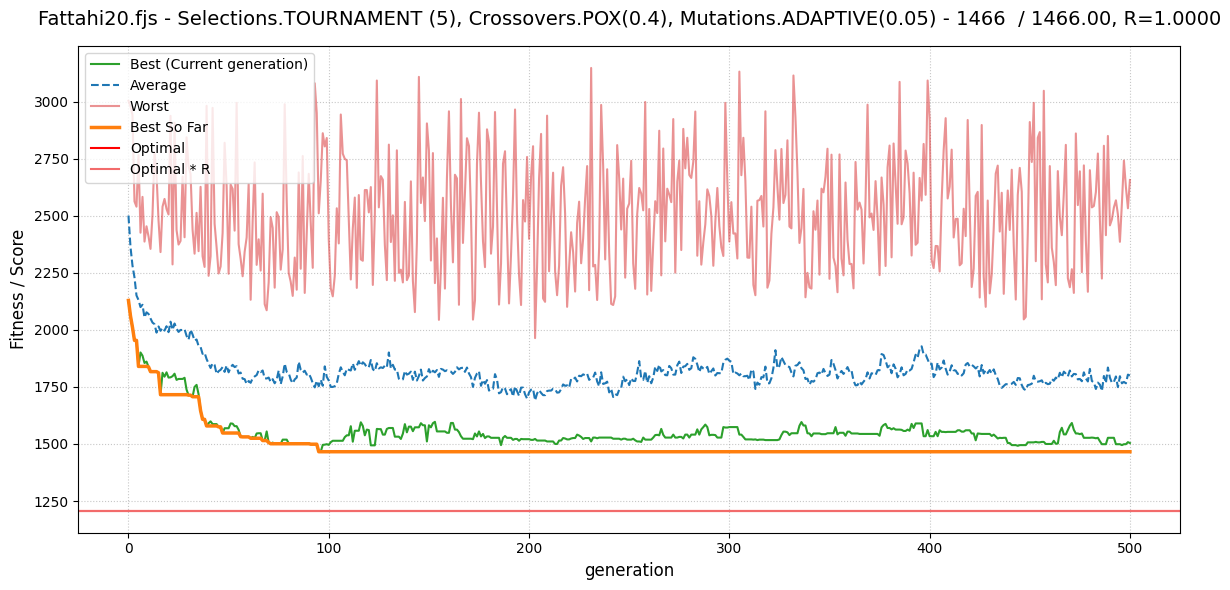

In [20]:
evaluate_method_with_params(base_method_params, encoding)

Solving: 100%|██████████| 500/500 [00:07<00:00, 67.22it/s]
2026-04-25 23:05:29,159 [WARNING] genetic_algorithm.solve(): Found 17024 clones total
Solving: 100%|██████████| 500/500 [00:07<00:00, 67.56it/s]
2026-04-25 23:05:36,582 [WARNING] genetic_algorithm.solve(): Found 19529 clones total
Solving: 100%|██████████| 500/500 [00:07<00:00, 68.44it/s]
2026-04-25 23:05:43,895 [WARNING] genetic_algorithm.solve(): Found 17498 clones total


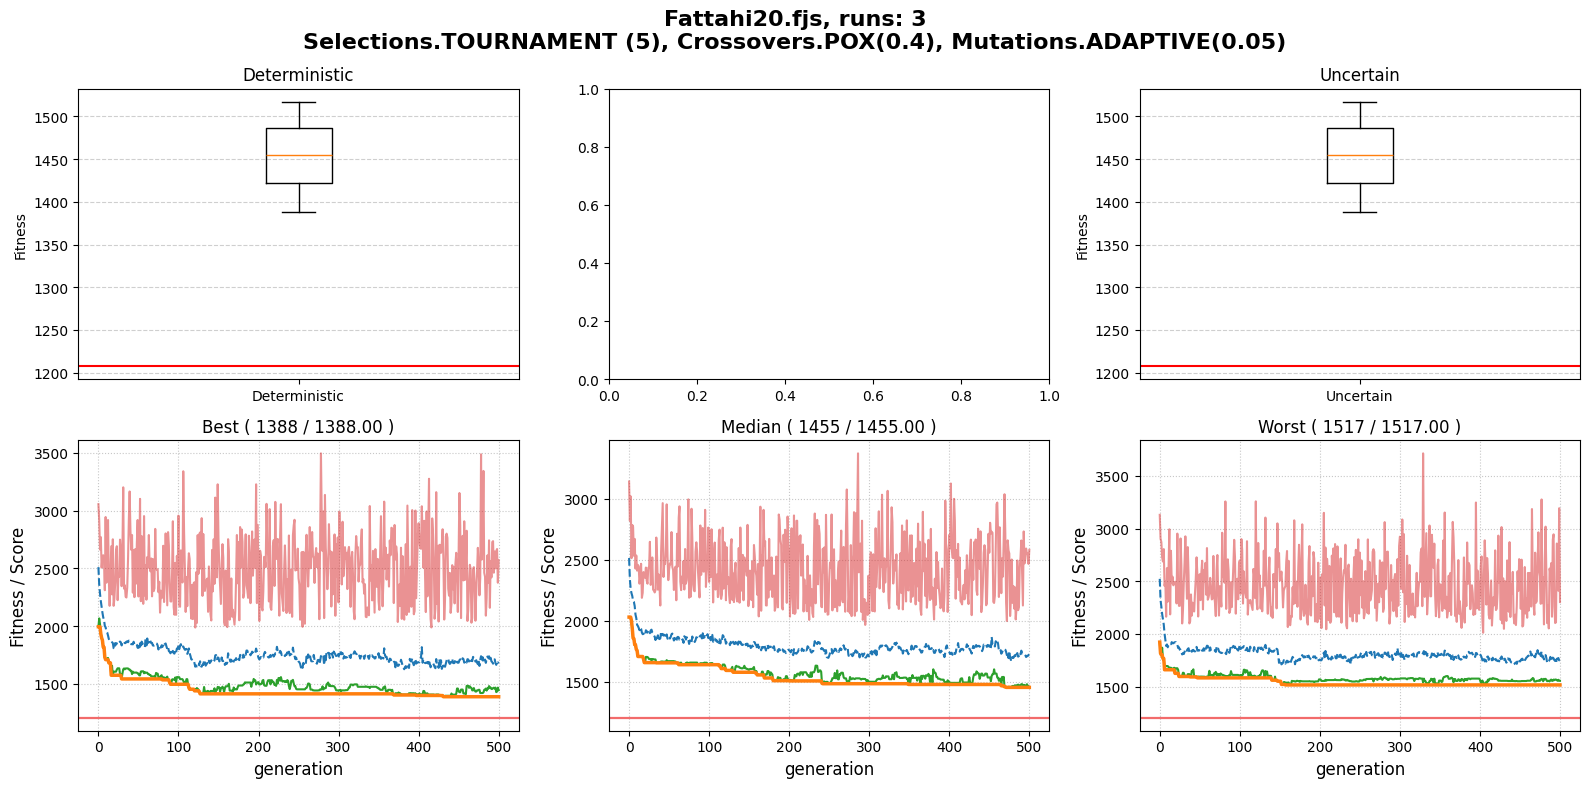

In [21]:
results = evaluate_method_with_params_for_stats(base_method_params, encoding, 3)